In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch 
import cpuinfo
import platform
import psutil
import time
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

In [3]:
import sys

from pathlib import Path

# Go up one level from notebooks/ to workspace root
BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR))

from src.training.train_bert import train
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def get_system_info():
    info = {
        "OS": platform.system(),
        "OS Version": platform.version(),
        "OS Release": platform.release(),
        "Architecture": platform.machine(),
        "Python Version": platform.python_version(),
        "CPU": cpuinfo.get_cpu_info()['brand_raw'],
        "CPU Cores": psutil.cpu_count(logical=False),
        "CPU Threads": psutil.cpu_count(logical=True),
        "RAM (GB)": round(psutil.virtual_memory().total / (1024 ** 3), 2),
        "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available",  
    }
    return info


console = Console()

def display_system_info(info):
    table = Table(show_header=False, box=None)
    for key, value in info.items():
        table.add_row(f"[bold cyan]{key}[/bold cyan]", f"{value}")
    panel = Panel(table, title="[bold magenta]System Information[/bold magenta]", border_style="magenta")
    console.print(panel)

display_system_info(info=get_system_info())

╭────────────────────────────────────────────── System Information ───────────────────────────────────────────────╮
│  OS              Linux                                                                                          │
│  OS Version      #15-Ubuntu SMP PREEMPT_DYNAMIC Wed Apr 22 16:06:43 UTC 2026                                    │
│  OS Release      7.0.0-15-generic                                                                               │
│  Architecture    x86_64                                                                                         │
│  Python Version  3.12.3                                                                                         │
│  CPU             AMD Ryzen 9 9950X 16-Core Processor                                                            │
│  CPU Cores       16                                                                                             │
│  CPU Threads     32                                                                                             │
│  RAM (GB)        59.46                                                                                          │
│  GPU             No GPU available                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
sample_size = 20000
device = "cpu"
bert = train(log_name=f"bert-{device}-{sample_size}", sample_size=sample_size)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


PyTorch version: 2.10.0+rocm7.2.2.git40d237bf
Requested device: cpu
CUDA available: False
       TRAIN (%)  TEST (%)  DEV (%)
label                              
0           50.0      50.0     50.0
1           50.0      50.0     50.0


wandb: Currently logged in as: amd-beast-owner (amd-beast-owner-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Map (num_proc=16):   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'test_loss': 0.40299639105796814, 'test_model_preparation_time': 0.0008, 'test_f1': 0.8159564133760928, 'test_runtime': 38.6457, 'test_samples_per_second': 517.522, 'test_steps_per_second': 32.345}
After train: None


In [12]:
import wandb
import pandas as pd

api = wandb.Api()

In [13]:
project_path = "amd-beast-owner/bert-finetuning"

In [29]:
cpu = api.run("amd-beast-owner-personal/bert-finetuning/f12ckwtp")
gpu = api.run("amd-beast-owner-personal/bert-finetuning/uhh7kmiv")

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df_cpu, df_gpu = cpu.history(), gpu.history()

df_cpu['device'] = 'AMD 9950X (CPU)'
df_gpu['device'] = 'AMD 9070 (GPU)'

df = pd.concat([df_cpu, df_gpu], ignore_index=True, axis=0)


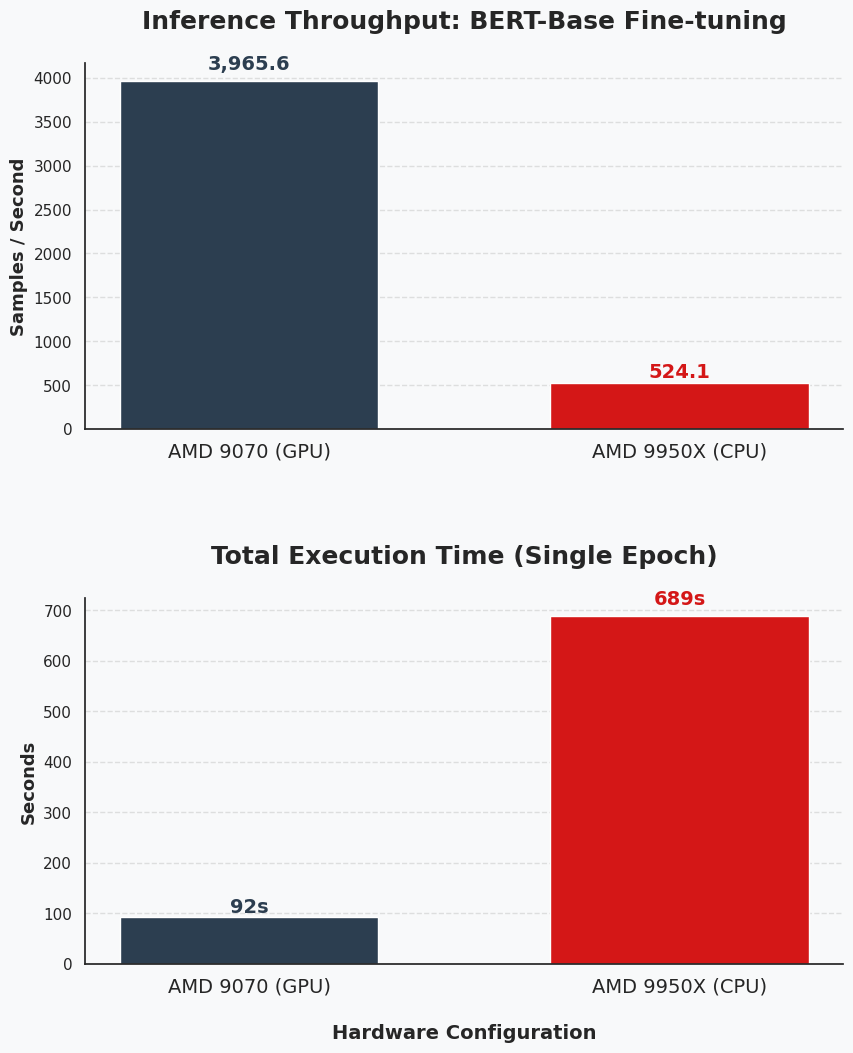

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), dpi=100)
fig.patch.set_facecolor('#f8f9fa') 

colors = ['#2c3e50', '#d41717']

avg_samples = df.groupby('device')['test/samples_per_second'].mean()
bars1 = ax1.bar(avg_samples.index, avg_samples.values, color=colors, width=0.6)

ax1.set_title('Inference Throughput: BERT-Base Fine-tuning', fontsize=18, fontweight='bold', pad=25)
ax1.set_ylabel('Samples / Second', fontsize=13, fontweight='semibold')
ax1.set_facecolor('#f8f9fa')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
             f'{height:,.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold', color=bar.get_facecolor())

max_runtime = df.groupby('device')['_runtime'].max()
bars2 = ax2.bar(max_runtime.index, max_runtime.values, color=colors, width=0.6)

ax2.set_title('Total Execution Time (Single Epoch)', fontsize=18, fontweight='bold', pad=25)
ax2.set_ylabel('Seconds', fontsize=13, fontweight='semibold')
ax2.set_xlabel('Hardware Configuration', fontsize=14, fontweight='semibold', labelpad=20)
ax2.set_facecolor('#f8f9fa')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
             f'{int(height)}s', ha='center', va='bottom', fontsize=14, fontweight='bold', color=bar.get_facecolor())

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6) # Subtle gridlines for context
    ax.tick_params(axis='x', labelsize=14)

plt.tight_layout(pad=5.0)
plt.show()